# Correlation Analysis of ACS Data Profiles and Places Data

In this file, we see the correlations between the ACS Profile Data and PLACES data.
PLACES data contains health-related metrics so it doesn't contain socioeconomic and demographic data.
To approach from the perspective of socioeconomic and demographic data, we will use the ACS Profile Data.

In [1]:
# data loading code is in load_data.py
from load_data import load_places, load_acs_profiles
# get the places data
df_places = load_places()
# get the ACS profiles data (This takes a while to load because it loads multiple files and merges them)
df_acs_profiles = load_acs_profiles()

df_acs_profiles.shape

(3222, 4353)

## Data Cleaning

## 1. Data Cleaning & Preprocessing

The ACS Profile dataset contains thousands of columns with various data suffixes (estimates, percentages, margins of error, etc.). In this section, we clean the dataset by:

1. Filtering for **Percent Estimate (PE)** columns. It is for ensuring a consistent scale (percentages).

    ACS dataset contains several columns. Each column suffix represents data types:

    | Symbol | Description                          | data type  |
    |:-------|:-------------------------------------|:-----------|
    | E      | Estimate                             | numeric    |
    | EA     | Estimate (Annotation)                | text       |
    | M      | Margin of Error                      | numeric    |
    | MA     | Margin of Error (Annotation)         | text       |
    | PE     | Percent Estimate                     | numeric    |
    | PEA    | Percent Estimate (Annotation)        | text       |
    | PM     | Percent Margin of Error              | numeric    |
    | PMA    | Percent Margin of Error (Annotation) | text       |
    | SS     | Statistical Significance             | text       |

    https://www.census.gov/data/developers/data-sets/acs-1year/data-notes.html

2. Handling and replacing invalid or missing Census codes (e.g., negative values) with `NaN`.
3. Dropping non-percentage columns (such as totals or counts).



In [2]:
columns = df_acs_profiles.columns
columns = [col for col in columns if col in ['CountyFIPS'] or col.endswith('PE')]
df_acs_profiles = df_acs_profiles[columns]
df_acs_profiles.shape

(3222, 543)

3,810 columns were removed.

Replace invalid values with NaN.
ACS Profile Data represents errors with extremely small numbers:

| Estimate Value | Meanint                                                                      |
|---------------:|:-----------------------------------------------------------------------------|
| -999999999     | The number of sample cases is too small.                                     |
| -888888888     | The estimate is not appilcable or not available.                             |
| -666666666     | No or few sample observations are available, or open-ended median intervals. |
| -555555555     | Estimate is controlled, and a statistical test for sampling variability is not appropriate.              |
| -333333333     | the median falls in the lowest interval or upper interval of an open-ended distribution, and a statistical test is not appropriate. |
| -222222222     | No sufficient sample for standard error calculation.                         |

(https://www.census.gov/data/developers/data-sets/acs-1year/data-notes.html)

Percent estimate value must not be negative, so we replace negative values with NaN.

In [3]:
for column in columns:
    if df_acs_profiles[column].dtype in ['int64', 'float64']:
        df_acs_profiles[column] = df_acs_profiles[column].map(lambda x: x if x >= 0 else None)

In [4]:
df_acs_profiles.info()


<class 'pandas.DataFrame'>
RangeIndex: 3222 entries, 0 to 3221
Columns: 543 entries, DP02_0001PE to DP05_0108PE
dtypes: float64(456), int64(45), object(41), str(1)
memory usage: 13.3+ MB


We have still object columns in the dataset.
It is the column with all NaN values.
We will those columns.

In [5]:
df_acs_profiles.shape

(3222, 543)

In [6]:
df_acs_profiles.dropna(axis=1, how='all', inplace=True)

In [7]:
df_acs_profiles.shape

(3222, 502)

We removed 41 columns.

In [8]:
df_acs_profiles.info()

<class 'pandas.DataFrame'>
RangeIndex: 3222 entries, 0 to 3221
Columns: 502 entries, DP02_0001PE to DP05_0108PE
dtypes: float64(456), int64(45), str(1)
memory usage: 12.3 MB


`int64` columns are total size columns.
For example, `DP03_0001PE` is the population 16 years and over (https://api.census.gov/data/2024/acs/acs1/profile/groups/DP03.html).
It is used as denominator to calculate percent estimate values such as `DP03_0002PE`, which is the percent value of labor force.

Confirm that all `int64` columns have values greater than 100.
It means the column is not a percent estimate column.
And remove them.

In [9]:

int_cols = df_acs_profiles.select_dtypes(include=["int64"])

# check if all integer columns have a maximum value more than 100.
# In other words, all integer columns have irregular values as they are not percentages.
result_series = int_cols.max() <= 100
assert result_series.sum() == 0

# drop all integer columns as they are not percentages
df_acs_profiles.drop(columns=int_cols.columns, inplace=True)
df_acs_profiles.shape

(3222, 457)

45 columns were removed.

In addition, remove columns that contain more than 100 values, because they are not percent estimate columns.

In [10]:
import numpy as np

numeric_cols = df_acs_profiles.select_dtypes(include=[np.number]).columns
valid_numeric_cols = numeric_cols[
    df_acs_profiles[numeric_cols].max() <= 100
]

non_numeric_cols = df_acs_profiles.select_dtypes(
    exclude=[np.number]
).columns

safe_cols = list(valid_numeric_cols) + list(non_numeric_cols)
df_acs_profiles = df_acs_profiles[safe_cols]

df_acs_profiles.shape

(3222, 433)

Then, 24 columns were removed.

We remove uncontrollable columns, such as race and ancestry columns.
To remove those columns, we get metadata and check the column information.

In [11]:
from load_data import load_acs_vars
df_acs_meta = load_acs_vars()
df_acs_meta.head()

,variables
for,"{'label': 'Census API FIPS 'for' clause', 'con..."
in,"{'label': 'Census API FIPS 'in' clause', 'conc..."
ucgid,{'label': 'Uniform Census Geography Identifier...
DP02_0126E,{'label': 'Estimate!!ANCESTRY!!Total populatio...
DP05_0050PE,{'label': 'Percent!!RACE!!Total population!!On...


Change metadata information to format that we can easily check the column information.

In [12]:
df_acs_meta['variable'] = df_acs_meta.index
import json
df_acs_meta['label'] = df_acs_meta['variables'].apply(lambda x: x['label'])
df_acs_meta['concept'] = df_acs_meta['variables'].apply(lambda x: x['concept'] if 'concept' in x else None)
df_acs_meta['predicateType'] = df_acs_meta['variables'].apply(lambda x: x['predicateType'] if 'predicateType' in x else None)
df_acs_meta['group'] = df_acs_meta['variables'].apply(lambda x: x['group'])
df_acs_meta['limit'] = df_acs_meta['variables'].apply(lambda x: x['limit'])
df_acs_meta['attributes'] = df_acs_meta['variables'].apply(lambda x: json.dumps(x['attributes']) if 'attributes' in x else None)
df_acs_meta['label_split'] = df_acs_meta['label'].apply(lambda x: x.split('!!') if '!!' in x else [x])
for i in range(7):
    df_acs_meta[f'label_{i+1}'] = df_acs_meta['label_split'].apply(lambda x: x[i] if len(x) > i else None)
df_acs_meta = df_acs_meta[df_acs_meta['variable'].str.endswith('PE') & ~df_acs_meta['variable'].str.contains('PR_')]
df_acs_meta.reset_index(drop=True, inplace=True)
df_acs_meta.head()

,variables,variable,label,concept,predicateType,group,limit,attributes,label_split,label_1,label_2,label_3,label_4,label_5,label_6,label_7
0,{'label': 'Percent!!RACE!!Total population!!On...,DP05_0050PE,Percent!!RACE!!Total population!!One race!!Bla...,ACS Demographic and Housing Estimates,float,DP05,0,"""DP05_0050PEA,DP05_0050PM,DP05_0050PMA""","[Percent, RACE, Total population, One race, Bl...",Percent,RACE,Total population,One race,Black or African American,Nigerian,NaN
1,{'label': 'Percent!!YEAR STRUCTURE BUILT!!Tota...,DP04_0016PE,Percent!!YEAR STRUCTURE BUILT!!Total housing u...,Selected Housing Characteristics,int,DP04,0,"""DP04_0016PEA,DP04_0016PM,DP04_0016PMA""","[Percent, YEAR STRUCTURE BUILT, Total housing ...",Percent,YEAR STRUCTURE BUILT,Total housing units,NaN,NaN,NaN,NaN
2,{'label': 'Percent!!SCHOOL ENROLLMENT!!Populat...,DP02_0054PE,Percent!!SCHOOL ENROLLMENT!!Population 3 years...,Selected Social Characteristics in the United ...,float,DP02,0,"""DP02_0054PEA,DP02_0054PM,DP02_0054PMA""","[Percent, SCHOOL ENROLLMENT, Population 3 year...",Percent,SCHOOL ENROLLMENT,Population 3 years and over enrolled in school,"Nursery school, preschool",NaN,NaN,NaN
3,{'label': 'Percent!!CLASS OF WORKER!!Civilian ...,DP03_0048PE,Percent!!CLASS OF WORKER!!Civilian employed po...,Selected Economic Characteristics,float,DP03,0,"""DP03_0048PEA,DP03_0048PM,DP03_0048PMA""","[Percent, CLASS OF WORKER, Civilian employed p...",Percent,CLASS OF WORKER,Civilian employed population 16 years and over,Government workers,NaN,NaN,NaN
4,{'label': 'Percent!!ROOMS!!Total housing units...,DP04_0029PE,Percent!!ROOMS!!Total housing units!!2 rooms,Selected Housing Characteristics,float,DP04,0,"""DP04_0029PEA,DP04_0029PM,DP04_0029PMA""","[Percent, ROOMS, Total housing units, 2 rooms]",Percent,ROOMS,Total housing units,2 rooms,NaN,NaN,NaN


In [13]:
# remove variables that can not be controlled by governments
except_categories = [
    'RACE', 'ANCESTRY', 'HISPANIC OR LATINO AND RACE',
    'Race alone or in combination with one or more other races',
    'WORLD REGION OF BIRTH OF FOREIGN-BORN',
    'PLACE OF BIRTH', 'YEAR OF ENTRY', 'LANGUAGE SPOKEN AT HOME',
    'SEX AND AGE',
    'U.S. CITIZENSHIP STATUS',
]

In [14]:
df_acs_meta = df_acs_meta[~df_acs_meta['label_2'].isin(except_categories)]


In [15]:
df_acs_profiles.shape

(3222, 433)

In [16]:
columns = df_acs_profiles.columns
columns = [
    col for col in columns
    if (not col.startswith('DP')) or (col in df_acs_meta['variable'].tolist())
]
df_acs_profiles = df_acs_profiles[columns]

In [17]:
df_acs_profiles.shape

(3222, 283)

150 columns were removed and the number of final candidate variables is 283.

## 2. Merging Datasets

Once the ACS profiles are cleaned, we merge them with the PLACES dataset using `CountyFIPS` indicators.


In [18]:
import pandas as pd
df = pd.merge(df_places[['CountyFIPS', 'MHLTH_AdjPrev']], df_acs_profiles, on='CountyFIPS', how='inner')

## 3. Spearman Correlation Analysis

To find socioeconomic factors that strongly associated with mental health distress (`MHLTH_AdjPrev`), we calculate correlation coefficients.
We use spearman correlation coefficient because ACS data is not always normally distributed and sometimes contains extreme outliers.
Spearman correlation coefficient solves the problem by using rank instead of value.

In [19]:
from scipy.stats import spearmanr
import pandas as pd

results = []

for col in df.select_dtypes(include='number').columns:
    if col != 'MHLTH_AdjPrev':
        rho, p = spearmanr(
            df[col],
            df['MHLTH_AdjPrev'],
            nan_policy='omit'
        )

        results.append({
            'Variable': col,
            'Spearman': rho,
            'p-value': p
        })

spearman_df = pd.DataFrame(results)


C:\Users\user\AppData\Local\Temp\ipykernel_436\2830295278.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import spearmanr


In [20]:

spearman_df['Absolute Spearman'] = spearman_df['Spearman'].abs()
spearman_df = spearman_df.sort_values(
    by='Absolute Spearman',
    ascending=False
)

spearman_df.head()

,Variable,Spearman,p-value,Absolute Spearman
48,DP02_0065PE,-0.723422,0.0,0.723422
51,DP02_0068PE,-0.682767,0.0,0.682767
134,DP03_0097PE,-0.675418,0.0,0.675418
55,DP02_0076PE,0.662468,0.0,0.662468
45,DP02_0062PE,0.657758,0.0,0.657758


Each variable p-value was calculated as zero


In [21]:
(spearman_df['Absolute Spearman'] > 0.5).sum()

np.int64(61)

## 4. Variable Clustering & Top Correlations

We clusterize the variables for high correlation in advance.
Here we use the information, and pickup top related variables in different clusters.

In [22]:
from load_data import load_acs_cluster
df_acs_cluster = load_acs_cluster()
df_acs_cluster.head()

,Column Name,cluster,subcluster
0,DP02_0124PE,NaN,NaN
1,DP02_0125PE,NaN,NaN
2,DP02_0126PE,NaN,NaN
3,DP02_0127PE,NaN,NaN
4,DP02_0128PE,NaN,NaN


In [23]:
spearman_df = spearman_df.merge(
    df_acs_cluster,
    left_on='Variable',
    right_on='Column Name',
    how='left'
)

In [24]:
spearman_df[(spearman_df['Absolute Spearman'] > 0.5)]['cluster'].value_counts()

cluster
Income            14
Poverty           12
House             12
Labor force        7
Education          5
Insurance          5
Disability         3
Digital access     2
Occupation         1
Name: count, dtype: int64

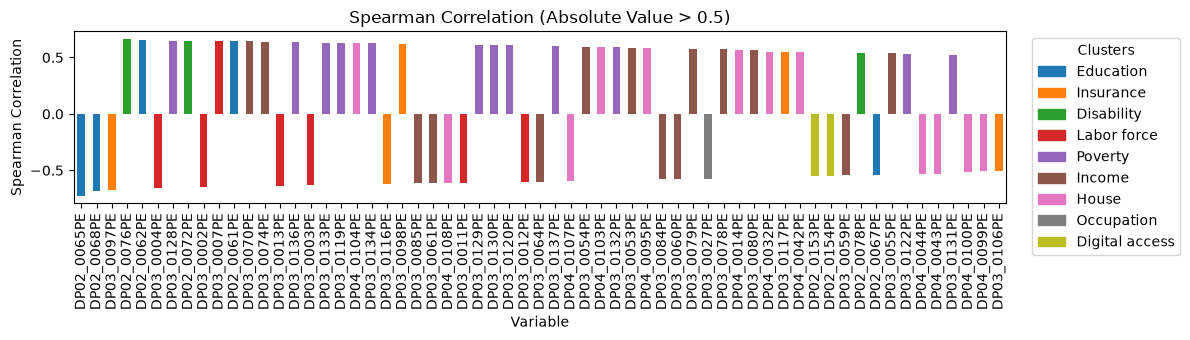

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

filtered_df = spearman_df[spearman_df["Absolute Spearman"] > 0.5].copy()

colors = plt.get_cmap("tab10")
clusters = filtered_df["cluster"].unique()
cluster_to_color = {
    cluster: colors(i) for i, cluster in enumerate(clusters)
}
bar_colors = filtered_df["cluster"].map(cluster_to_color)

fig, ax = plt.subplots(figsize=(12, 3.5))

filtered_df.plot.bar(
    x="Variable",
    y="Spearman",
    color=bar_colors,
    rot=90,
    title="Spearman Correlation (Absolute Value > 0.5)",
    ax=ax,
    legend=False,
)

from matplotlib.patches import Patch

legend_handles = [
    Patch(color=cluster_to_color[cluster], label=f"{cluster}")
    for cluster in clusters
]
ax.legend(
    handles=legend_handles, title="Clusters", bbox_to_anchor=(1.02, 1), loc="upper left"
)

plt.ylabel("Spearman Correlation")
plt.tight_layout()
plt.show()

In [26]:
variables = [
    'DP02_0065PE',
    'DP03_0097PE',
    'DP02_0076PE',
    'DP03_0004PE',
    'DP03_0128PE',
]

In [27]:
df_acs_meta['note'] = df_acs_meta['label_split'].map(lambda x: " / ".join(x))

In [28]:
pd.merge(
    spearman_df[spearman_df['Variable'].isin(variables)].sort_values(by='Absolute Spearman', ascending=False),
    df_acs_meta,
    left_on='Variable',
    right_on='variable',
)[['Variable', 'Spearman', 'cluster', 'note']].style.set_properties(
    subset=['note'],
    **{
        'text-align': 'left',
        'white-space': 'pre-wrap',
    }
).set_table_styles([
    {'selector': 'th.col3', 'props': [('text-align', 'left')]}
])

,Variable,Spearman,cluster,note
0,DP02_0065PE,-0.723422,Education,Percent / EDUCATIONAL ATTAINMENT / Population 25 years and over / Bachelor's degree
1,DP03_0097PE,-0.675418,Insurance,Percent / HEALTH INSURANCE COVERAGE / Civilian noninstitutionalized population / With health insurance coverage / With private health insurance
2,DP02_0076PE,0.662468,Disability,Percent / DISABILITY STATUS OF THE CIVILIAN NONINSTITUTIONALIZED POPULATION / 18 to 64 years / With a disability
3,DP03_0004PE,-0.655491,Labor force,Percent / EMPLOYMENT STATUS / Population 16 years and over / In labor force / Civilian labor force / Employed
4,DP03_0128PE,0.648141,Poverty,Percent / PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL / All people


Education, Insurance, Disabillity, Labor force and Poverty are top related variables and clusters.